<a href="https://colab.research.google.com/github/abhinav-phi/nids/blob/main/nids-backend/notebooks/colab/02_Training_GPU_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Model Training · T4 GPU Edition · *The Sentinel* NIDS

Colab port of `src/model/train.py` + `notebooks/02_training*.ipynb`, upgraded
for the **NVIDIA T4** runtime.

**Pipeline** (mirrors production `train.py`):

```
CICIDS2017 CSV (2.5M rows)
  └─ chunked stratified sampling → ~400k rows   (train.py::load_data)
       └─ clean: inf→NaN, dropna, drop_duplicates   (clean_data)
            └─ LabelEncoder (7 classes) + stratified 80/20 split
                 └─ StandardScaler + RobustScaler  (dual-scaler comparison)
                      └─ model arena — ranked by MACRO F1:
                           • Logistic Regression        (CPU)
                           • Decision Tree              (CPU)
                           • Random Forest              (CPU)
                           • XGBoost                    (⚡ T4 GPU)
                           • LightGBM                   (CPU)
                           • PyTorch MLP 256-128-64     (⚡ T4 GPU, replaces sklearn MLP)
```

**GPU requirement** — Runtime → Change runtime type → **T4 GPU** before running.

**Outputs** → `/content/nids_artifacts/`: `model.pkl`, `scaler.pkl`,
`robust_scaler.pkl`, `label_encoder.pkl`, `feature_names.json`,
`manifest.json`, `model_torch.pt` — then synced to Drive & zipped for download.
`03_Inference_API_Colab.ipynb` and `04_Dashboard_Colab.ipynb` consume these.

⏱ Expected runtime on T4: ~30–45 min (data load ~5 min + models ~25 min).

In [4]:
# Colab already ships torch / xgboost / lightgbm / sklearn — only these are missing:
!pip install -q shap imbalanced-learn optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 26.6 MB/s eta 0:00:00


In [5]:
import subprocess
import torch

print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
                      "--format=csv"], capture_output=True, text=True).stdout)
GPU_OK = torch.cuda.is_available()
print(f"CUDA available : {GPU_OK}")
if GPU_OK:
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("=" * 70)
    print("⚠️  NO GPU — go to Runtime → Change runtime type → T4 GPU, then re-run.")
    print("    (The notebook still works on CPU — only slower.)")
    print("=" * 70)

name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07

CUDA available : True
GPU            : Tesla T4
VRAM           : 14.6 GB


## ⚙️ Step 1 — Config: dataset + artifact directory

In [6]:
import os
import shutil
import zipfile
from pathlib import Path

DRIVE_DATA_DIR = "nids_data"        # MyDrive folder with the dataset CSV
DRIVE_ART_DIR  = "nids_artifacts"   # MyDrive folder artifacts get synced to
DATA_FILENAME  = "cicids2017_cleaned.csv"
LABEL_COL      = "Attack Type"
SAMPLE_TARGET  = 400_000            # stratified sample size (train.py default)
USE_SMOTE      = False              # production keeps SMOTE off (class_weight instead)

ART_DIR = Path("/content/nids_artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)

# ── locate dataset ────────────────────────────────────────────────────────
DATA_PATH = None
try:
    from google.colab import drive
    drive.mount("/content/drive")
    cand = Path("/content/drive/MyDrive") / DRIVE_DATA_DIR / DATA_FILENAME
    if cand.exists():
        DATA_PATH = cand
except Exception as e:
    print(f"(Drive unavailable: {e})")

if DATA_PATH is None:
    for cand in [Path("/content") / DATA_FILENAME,
                 Path("../data/raw") / DATA_FILENAME]:
        if cand.exists():
            DATA_PATH = cand
            break

assert DATA_PATH is not None, (
    f"Dataset not found! Upload {DATA_FILENAME} to MyDrive/{DRIVE_DATA_DIR}/ and re-run."
)
print(f"✔ Dataset : {DATA_PATH}  ({DATA_PATH.stat().st_size / 1024**3:.2f} GB)")
print(f"✔ Artifacts → {ART_DIR}")
print(f"✔ Sample target: {SAMPLE_TARGET:,} rows | SMOTE: {USE_SMOTE}")

Mounted at /content/drive
✔ Dataset : /content/drive/MyDrive/nids_data/cicids2017_cleaned.csv  (0.67 GB)
✔ Artifacts → /content/nids_artifacts
✔ Sample target: 400,000 rows | SMOTE: False


In [7]:
import json
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# reproducibility (train.py convention)
SEED = 42

def seed_everything(seed: int = SEED):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()
print(f"pandas {pd.__version__} | sklearn {__import__('sklearn').__version__} "
      f"| xgboost {__import__('xgboost').__version__} "
      f"| torch {torch.__version__}")

pandas 2.2.3 | sklearn 1.6.1 | xgboost 3.4.1 | torch 2.11.0+cu128


## 📥 Step 2 — Chunked, stratified loading (~400k rows)

Port of `train.py::load_data` — two passes over the CSV:
1. count rows per class (read only the label column)
2. re-read in chunks and sample **each class proportionally**, so rare attack
   classes survive the downsampling. Features are read as `float32` (Colab RAM).

In [8]:
from collections import Counter

def load_stratified(csv_path: Path, target_rows: int = SAMPLE_TARGET,
                    chunksize: int = 250_000) -> pd.DataFrame:
    # pass 1 — class counts
    counts: Counter = Counter()
    for chunk in pd.read_csv(csv_path, usecols=[LABEL_COL], chunksize=chunksize):
        counts.update(chunk[LABEL_COL].value_counts().to_dict())
    total = sum(counts.values())
    frac = min(1.0, target_rows / total)
    print(f"Pass 1: {total:,} total rows across {len(counts)} classes")
    for cls, n in sorted(counts.items(), key=lambda kv: -kv[1]):
        print(f"   {cls:<24} {n:>10,}")
    print(f"Sampling fraction: {frac:.4f}  → target ≈ {target_rows:,} rows")

    # pass 2 — per-class proportional sampling per chunk
    dtype_map = {c: ("str" if c.strip() == LABEL_COL else "float32")
                 for c in pd.read_csv(csv_path, nrows=0).columns}
    frames = []
    for chunk in pd.read_csv(csv_path, chunksize=chunksize, dtype=dtype_map):
        chunk.columns = chunk.columns.str.strip()
        if frac < 1.0:
            chunk = chunk.groupby(LABEL_COL, group_keys=False).apply(
                lambda g: g.sample(n=max(1, int(len(g) * frac)), random_state=SEED))
        frames.append(chunk)
        print(f"   chunk {len(frames):02d} → running total {sum(len(f) for f in frames):,}", end="\r")
    combined = pd.concat(frames, ignore_index=True)
    print(f"\nLoaded & sampled: {len(combined):,} rows × {combined.shape[1]} cols")
    return combined

t0 = time.time()
df = load_stratified(DATA_PATH)
print(f"Load time: {time.time() - t0:.1f}s")

Pass 1: 2,520,751 total rows across 7 classes
   Normal Traffic            2,095,057
   DoS                         193,745
   DDoS                        128,014
   Port Scanning                90,694
   Brute Force                   9,150
   Web Attacks                   2,143
   Bots                          1,948
Sampling fraction: 0.1587  → target ≈ 400,000 rows
   chunk 11 → running total 399,986
Loaded & sampled: 399,986 rows × 53 cols
Load time: 35.3s


## 🧹 Step 3 — Cleaning (port of `clean_data`)

`inf → NaN → drop`, then drop duplicates. Flow-duration can be 0 in the raw
export which produces `inf` rates — those rows are unusable.

In [9]:
original = len(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f"Removed {original - len(df):,} bad rows → {len(df):,} remaining")
print("\nClass distribution after cleaning:")
print(df[LABEL_COL].value_counts().to_string())

Removed 553 bad rows → 399,433 remaining

Class distribution after cleaning:
Attack Type
Normal Traffic    331889
DoS                30741
DDoS               20313
Port Scanning      14391
Brute Force         1450
Web Attacks          340
Bots                 309


## 🏷️ Step 4 — Features, labels, encoding, split

In [10]:
X = df.drop(columns=[LABEL_COL])
y = df[LABEL_COL]

non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Dropping non-numeric columns: {non_numeric}")
    X.drop(columns=non_numeric, inplace=True)

le = LabelEncoder()
y_enc = le.fit_transform(y)
joblib.dump(le, ART_DIR / "label_encoder.pkl")

print(f"Features: {X.shape[1]}  |  Classes: {len(le.classes_)}")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} → {cls:<24} ({int((y_enc == i).sum()):>8,} samples)")

# stratified 80/20 split (train.py convention: random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_enc, test_size=0.2, stratify=y_enc, random_state=SEED
)

# persist the holdout exactly like train.py (data/processed/)
np.save(ART_DIR / "X_test.npy", X_test.astype(np.float32))
np.save(ART_DIR / "y_test.npy", y_test)
# and the exact feature order — the inference contract
(ART_DIR / "feature_names.json").write_text(json.dumps(list(X.columns), indent=2))

print(f"\nTrain: {len(X_train):,}   Test: {len(X_test):,}")
print("Saved: X_test.npy, y_test.npy, feature_names.json, label_encoder.pkl")

Features: 52  |  Classes: 7
   0 → Bots                     (     309 samples)
   1 → Brute Force              (   1,450 samples)
   2 → DDoS                     (  20,313 samples)
   3 → DoS                      (  30,741 samples)
   4 → Normal Traffic           ( 331,889 samples)
   5 → Port Scanning            (  14,391 samples)
   6 → Web Attacks              (     340 samples)

Train: 319,546   Test: 79,887
Saved: X_test.npy, y_test.npy, feature_names.json, label_encoder.pkl


## ⚖️ Step 5 — Class imbalance

**Production choice (`train.py`)**: `class_weight="balanced"` — SMOTE is
present but disabled (`USE_SMOTE=False`), because SMOTE on 400k rows is slow
and tree models handle weighting well. Flip the flag in Step 1 to experiment.

In [11]:
if USE_SMOTE:
    from imblearn.over_sampling import SMOTE
    # cap the training set so SMOTE can't explode Colab RAM
    cap = 300_000
    if len(X_train) > cap:
        idx = np.random.RandomState(SEED).choice(len(X_train), cap, replace=False)
        X_tr_sub, y_tr_sub = X_train[idx], y_train[idx]
        print(f"Capped train {len(X_train):,} → {cap:,} for SMOTE")
    else:
        X_tr_sub, y_tr_sub = X_train, y_train
    print("Applying SMOTE…")
    smote = SMOTE(random_state=SEED, k_neighbors=5)
    X_train_bal, y_train_bal = smote.fit_resample(X_tr_sub, y_tr_sub)
    print(f"After SMOTE: {len(X_train_bal):,} samples")
else:
    X_train_bal, y_train_bal = X_train, y_train
    counts = np.bincount(y_train, minlength=len(le.classes_))
    print("SMOTE off (production default) — class_weight handles imbalance.")
    print("Training class distribution:")
    for i, c in enumerate(counts):
        print(f"  {le.classes_[i]:<24} {c:>9,}")

SMOTE off (production default) — class_weight handles imbalance.
Training class distribution:
  Bots                           247
  Brute Force                  1,160
  DDoS                        16,250
  DoS                         24,593
  Normal Traffic             265,511
  Port Scanning               11,513
  Web Attacks                    272


## 📏 Step 6 — Dual scalers (port of `scale_dual`)

- **StandardScaler** → saved as `scaler.pkl` — **this is the production scaler**
- **RobustScaler** → `robust_scaler.pkl` — median/IQR, unaffected by DDoS
  outliers; compared but not deployed

Both are fit on training data only, then applied to the test set.

In [12]:
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train_bal)
X_test_std  = std_scaler.transform(X_test)
joblib.dump(std_scaler, ART_DIR / "scaler.pkl")

rob_scaler = RobustScaler()
X_train_rob = rob_scaler.fit_transform(X_train_bal)
X_test_rob  = rob_scaler.transform(X_test)
joblib.dump(rob_scaler, ART_DIR / "robust_scaler.pkl")

print(f"StandardScaler → scaler.pkl         (train mean={X_train_std.mean():.4f}, std={X_train_std.std():.4f})")
print(f"RobustScaler   → robust_scaler.pkl")

StandardScaler → scaler.pkl         (train mean=0.0000, std=1.0000)
RobustScaler   → robust_scaler.pkl


## 🏟️ Step 7 — The model arena

Helper `train_eval()` (port of `train.py::train_eval`) records Accuracy,
**Macro F1** (the ranking metric — robust to imbalance), Weighted F1,
Precision, Recall and wall-clock time for every model.

In [13]:
RESULTS = []

def train_eval(model, name, X_tr, y_tr, X_te, y_te, device="CPU"):
    print(f"Training [{name}] on {device} …")
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    f1m  = f1_score(y_te, y_pred, average="macro", zero_division=0)
    f1w  = f1_score(y_te, y_pred, average="weighted", zero_division=0)
    prec = precision_score(y_te, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_te, y_pred, average="macro", zero_division=0)
    print(f"  ✔ Acc={acc*100:6.2f}%  MacroF1={f1m*100:6.2f}%  "
          f"Prec={prec*100:6.2f}%  Rec={rec*100:6.2f}%  {elapsed:6.1f}s  [{device}]")
    RESULTS.append({
        "Model": name, "Device": device,
        "Accuracy": round(acc * 100, 2), "Macro F1": round(f1m * 100, 2),
        "Weighted F1": round(f1w * 100, 2), "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2), "Time (s)": round(elapsed, 1),
        "_model": model, "_y_pred": y_pred,
    })
    return RESULTS[-1]

def make_xgb(n_estimators=300, max_depth=6, learning_rate=0.1, device="cuda", **extra):
    """XGBClassifier that prefers the GPU and degrades gracefully:
    xgboost ≥2.0 → device='cuda'; older → tree_method='gpu_hist'; else CPU.
    Extra kwargs (Optuna-tuned subsample / colsample_bytree / min_child_weight)
    override the defaults."""
    common = dict(n_estimators=n_estimators, max_depth=max_depth,
                  learning_rate=learning_rate, subsample=0.8,
                  colsample_bytree=0.8, random_state=SEED,
                  eval_metric="mlogloss", verbosity=0, n_jobs=-1)
    common.update(extra)
    try:
        return XGBClassifier(device=device, tree_method="hist", **common), device.upper()
    except (TypeError, ValueError):
        pass
    if device == "cuda":
        try:
            return XGBClassifier(tree_method="gpu_hist", **common), "GPU (gpu_hist)"
        except (TypeError, ValueError):
            pass
    return XGBClassifier(**common), "CPU"

### 7.1 — Logistic Regression (baseline · CPU)

In [14]:
train_eval(
    LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced",
                       n_jobs=-1, random_state=SEED),
    "Logistic Regression", X_train_std, y_train_bal, X_test_std, y_test,
)

Training [Logistic Regression] on CPU …
  ✔ Acc= 83.17%  MacroF1= 54.50%  Prec= 50.29%  Rec= 95.00%    67.8s  [CPU]


{'Model': 'Logistic Regression',
 'Device': 'CPU',
 'Accuracy': 83.17,
 'Macro F1': 54.5,
 'Weighted F1': 88.42,
 'Precision': 50.29,
 'Recall': 95.0,
 'Time (s)': 67.8,
 '_model': LogisticRegression(class_weight='balanced', max_iter=2000, n_jobs=-1,
                    random_state=42),
 '_y_pred': array([4, 0, 4, ..., 4, 4, 4])}

### 7.2 — Decision Tree (CPU)

In [15]:
train_eval(
    DecisionTreeClassifier(max_depth=20, min_samples_split=5,
                           class_weight="balanced", random_state=SEED),
    "Decision Tree", X_train_std, y_train_bal, X_test_std, y_test,
)

Training [Decision Tree] on CPU …
  ✔ Acc= 99.75%  MacroF1= 92.30%  Prec= 90.48%  Rec= 97.07%    12.3s  [CPU]


{'Model': 'Decision Tree',
 'Device': 'CPU',
 'Accuracy': 99.75,
 'Macro F1': 92.3,
 'Weighted F1': 99.77,
 'Precision': 90.48,
 'Recall': 97.07,
 'Time (s)': 12.3,
 '_model': DecisionTreeClassifier(class_weight='balanced', max_depth=20,
                        min_samples_split=5, random_state=42),
 '_y_pred': array([4, 4, 4, ..., 4, 4, 4])}

### 7.3 — Random Forest (CPU)

In [16]:
train_eval(
    RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1,
                           class_weight="balanced", random_state=SEED),
    "Random Forest", X_train_std, y_train_bal, X_test_std, y_test,
)

Training [Random Forest] on CPU …
  ✔ Acc= 99.85%  MacroF1= 94.93%  Prec= 94.70%  Rec= 95.51%   185.2s  [CPU]


{'Model': 'Random Forest',
 'Device': 'CPU',
 'Accuracy': 99.85,
 'Macro F1': 94.93,
 'Weighted F1': 99.85,
 'Precision': 94.7,
 'Recall': 95.51,
 'Time (s)': 185.2,
 '_model': RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                        n_jobs=-1, random_state=42),
 '_y_pred': array([4, 4, 4, ..., 4, 4, 4])}

### 7.4 — XGBoost ⚡ (T4 GPU)

First a quick **CPU vs GPU timing bake-off** on identical hyper-parameters,
then the real GPU-trained model enters the arena.

In [17]:
xgb_cpu, _ = make_xgb(n_estimators=120, device="cpu")
r_cpu = train_eval(xgb_cpu, "XGBoost (timing, CPU)", X_train_std, y_train_bal, X_test_std, y_test, "CPU")
RESULTS.pop()  # timing runs are not arena contestants

if GPU_OK:
    xgb_probe, _ = make_xgb(n_estimators=120, device="cuda")
    r_gpu = train_eval(xgb_probe, "XGBoost (timing, GPU)", X_train_std, y_train_bal, X_test_std, y_test, "GPU")
    RESULTS.pop()
    speedup = r_cpu["Time (s)"] / max(r_gpu["Time (s)"], 1e-9)
    print(f"\n⚡ T4 speed-up on this data: {speedup:.1f}×  "
          f"(CPU {r_cpu['Time (s)']}s → GPU {r_gpu['Time (s)']}s)")

Training [XGBoost (timing, CPU)] on CPU …
  ✔ Acc= 99.91%  MacroF1= 96.96%  Prec= 98.90%  Rec= 95.38%    59.1s  [CPU]
Training [XGBoost (timing, GPU)] on GPU …
  ✔ Acc= 99.91%  MacroF1= 96.95%  Prec= 98.86%  Rec= 95.39%     6.1s  [GPU]

⚡ T4 speed-up on this data: 9.7×  (CPU 59.1s → GPU 6.1s)


In [18]:
xgb_gpu, xgb_dev = make_xgb(n_estimators=300, max_depth=6, learning_rate=0.1,
                            device="cuda" if GPU_OK else "cpu")
res_xgb = train_eval(xgb_gpu, "XGBoost", X_train_std, y_train_bal, X_test_std, y_test, xgb_dev)

Training [XGBoost] on CUDA …
  ✔ Acc= 99.92%  MacroF1= 97.24%  Prec= 98.72%  Rec= 96.05%    12.5s  [CUDA]


### 7.5 — LightGBM (CPU — deployed model family)

LightGBM's GPU build is fragile on Colab; on CPU it is already fast and it is
the family the production backend deploys (`LGBMClassifier`).

In [19]:
train_eval(
    LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                   num_leaves=63, class_weight="balanced",
                   n_jobs=-1, random_state=SEED, verbose=-1),
    "LightGBM", X_train_std, y_train_bal, X_test_std, y_test,
)

Training [LightGBM] on CPU …
  ✔ Acc= 99.90%  MacroF1= 97.28%  Prec= 97.15%  Rec= 97.42%   148.2s  [CPU]


{'Model': 'LightGBM',
 'Device': 'CPU',
 'Accuracy': 99.9,
 'Macro F1': 97.28,
 'Weighted F1': 99.9,
 'Precision': 97.15,
 'Recall': 97.42,
 'Time (s)': 148.2,
 '_model': LGBMClassifier(class_weight='balanced', max_depth=6, n_estimators=300,
                n_jobs=-1, num_leaves=63, random_state=42, verbose=-1),
 '_y_pred': array([4, 4, 4, ..., 4, 4, 4])}

### 7.6 — Neural Network ⚡ (PyTorch on T4)

GPU-native replacement for `train.py`'s `MLPClassifier(256, 128, 64)`:
same architecture, plus BatchNorm + Dropout, **class-weighted loss** (in
place of `class_weight="balanced"`), Adam, and early stopping on a 10 %
validation split. Every epoch runs on the T4.

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

DEVICE = torch.device("cuda" if GPU_OK else "cpu")

class SentinelMLP(nn.Module):
    """256-128-64 MLP — mirrors train.py's MLPClassifier architecture."""
    def __init__(self, in_dim: int, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.net(x)

def train_torch_mlp(X_tr, y_tr, X_te, y_te, epochs=30, batch_size=1024, lr=1e-3,
                    patience=5, verbose=True):
    """Train on DEVICE with class-weighted CE + early stopping.
    Returns (y_pred, best_val_loss, train_seconds)."""
    X_tr = np.asarray(X_tr, dtype=np.float32)
    X_te = np.asarray(X_te, dtype=np.float32)

    # 10% validation split for early stopping (like train.py's MLPClassifier)
    n = len(X_tr)
    rng = np.random.RandomState(SEED)
    perm = rng.permutation(n)
    n_val = max(1, int(n * 0.1))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_tr_t  = torch.tensor(X_tr[tr_idx])
    y_tr_t  = torch.tensor(np.asarray(y_tr)[tr_idx], dtype=torch.long)
    X_val_t = torch.tensor(X_tr[val_idx])
    y_val_t = torch.tensor(np.asarray(y_tr)[val_idx], dtype=torch.long)

    # class weights ← counts (equivalent of class_weight='balanced')
    counts = np.bincount(y_tr, minlength=len(le.classes_)).astype(np.float32)
    weights = torch.tensor(counts.sum() / (len(counts) * counts),
                           dtype=torch.float32, device=DEVICE)

    model = SentinelMLP(X_tr.shape[1], len(le.classes_)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)

    best_val, best_state, bad_epochs = float("inf"), None, 0
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            if xb.size(0) > 1:                 # BatchNorm needs >1 sample
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t.to(DEVICE)), y_val_t.to(DEVICE)).item()
        scheduler.step(val_loss)
        if verbose:
            print(f"  epoch {epoch:02d}  val_loss={val_loss:.4f}")
        if val_loss < best_val - 1e-4:
            best_val, bad_epochs = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch} (patience={patience})")
                break
    train_seconds = time.time() - t0

    if best_state is not None:
        model.load_state_dict(best_state)

    # batched test prediction
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_te), 8192):
            logits = model(torch.tensor(X_te[i:i + 8192]).to(DEVICE))
            preds.append(logits.argmax(dim=1).cpu().numpy())
    y_pred = np.concatenate(preds)
    return model, y_pred, best_val, train_seconds

In [21]:
torch_model, y_pred_mlp, best_val, mlp_seconds = train_torch_mlp(
    X_train_std, y_train_bal, X_test_std, y_test
)
acc  = accuracy_score(y_test, y_pred_mlp)
f1m  = f1_score(y_test, y_pred_mlp, average="macro", zero_division=0)
f1w  = f1_score(y_test, y_pred_mlp, average="weighted", zero_division=0)
prec = precision_score(y_test, y_pred_mlp, average="macro", zero_division=0)
rec  = recall_score(y_test, y_pred_mlp, average="macro", zero_division=0)
print(f"\n✔ [PyTorch MLP] Acc={acc*100:.2f}%  MacroF1={f1m*100:.2f}%  "
      f"Prec={prec*100:.2f}%  Rec={rec*100:.2f}%  {mlp_seconds:.1f}s  [{DEVICE}]")

RESULTS.append({
    "Model": "PyTorch MLP (GPU)", "Device": str(DEVICE),
    "Accuracy": round(acc * 100, 2), "Macro F1": round(f1m * 100, 2),
    "Weighted F1": round(f1w * 100, 2), "Precision": round(prec * 100, 2),
    "Recall": round(rec * 100, 2), "Time (s)": round(mlp_seconds, 1),
    "_model": torch_model, "_y_pred": y_pred_mlp, "_torch": True,
})
torch.save(torch_model.state_dict(), ART_DIR / "model_torch.pt")

  epoch 01  val_loss=0.2590
  epoch 02  val_loss=0.1895
  epoch 03  val_loss=0.1480
  epoch 04  val_loss=0.1443
  epoch 05  val_loss=0.1267
  epoch 06  val_loss=0.1338
  epoch 07  val_loss=0.1236
  epoch 08  val_loss=0.1217
  epoch 09  val_loss=0.1609
  epoch 10  val_loss=0.1267
  epoch 11  val_loss=0.1225
  epoch 12  val_loss=0.1111
  epoch 13  val_loss=0.1053
  epoch 14  val_loss=0.0956
  epoch 15  val_loss=0.0926
  epoch 16  val_loss=0.0893
  epoch 17  val_loss=0.0914
  epoch 18  val_loss=0.0946
  epoch 19  val_loss=0.0858
  epoch 20  val_loss=0.0887
  epoch 21  val_loss=0.1059
  epoch 22  val_loss=0.0849
  epoch 23  val_loss=0.0922
  epoch 24  val_loss=0.0950
  epoch 25  val_loss=0.0811
  epoch 26  val_loss=0.0882
  epoch 27  val_loss=0.0908
  epoch 28  val_loss=0.0891
  epoch 29  val_loss=0.0824
  epoch 30  val_loss=0.0802

✔ [PyTorch MLP] Acc=92.27%  MacroF1=65.32%  Prec=57.86%  Rec=97.79%  86.0s  [cuda]


## 🏆 Step 8 — Model comparison (ranked by Macro F1)

In [22]:
cols = ["Model", "Device", "Accuracy", "Macro F1", "Weighted F1",
        "Precision", "Recall", "Time (s)"]
comparison = (pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                            for r in RESULTS])[cols]
              .sort_values("Macro F1", ascending=False).reset_index(drop=True))
comparison.index += 1
comparison.index.name = "Rank"

print("=" * 96)
print("  MODEL ARENA — sorted by Macro F1")
print("=" * 96)
print(comparison.to_string())
print("=" * 96)
best_row = comparison.iloc[0]
print(f"\n🏆 Winner: {best_row['Model']}  |  Macro F1 {best_row['Macro F1']}%  [{best_row['Device']}]")

  MODEL ARENA — sorted by Macro F1
                    Model Device  Accuracy  Macro F1  Weighted F1  Precision  Recall  Time (s)
Rank                                                                                          
1                LightGBM    CPU     99.90     97.28        99.90      97.15   97.42     148.2
2                 XGBoost   CUDA     99.92     97.24        99.91      98.72   96.05      12.5
3           Random Forest    CPU     99.85     94.93        99.85      94.70   95.51     185.2
4           Decision Tree    CPU     99.75     92.30        99.77      90.48   97.07      12.3
5       PyTorch MLP (GPU)   cuda     92.27     65.32        93.71      57.86   97.79      86.0
6     Logistic Regression    CPU     83.17     54.50        88.42      50.29   95.00      67.8

🏆 Winner: LightGBM  |  Macro F1 97.28%  [CPU]


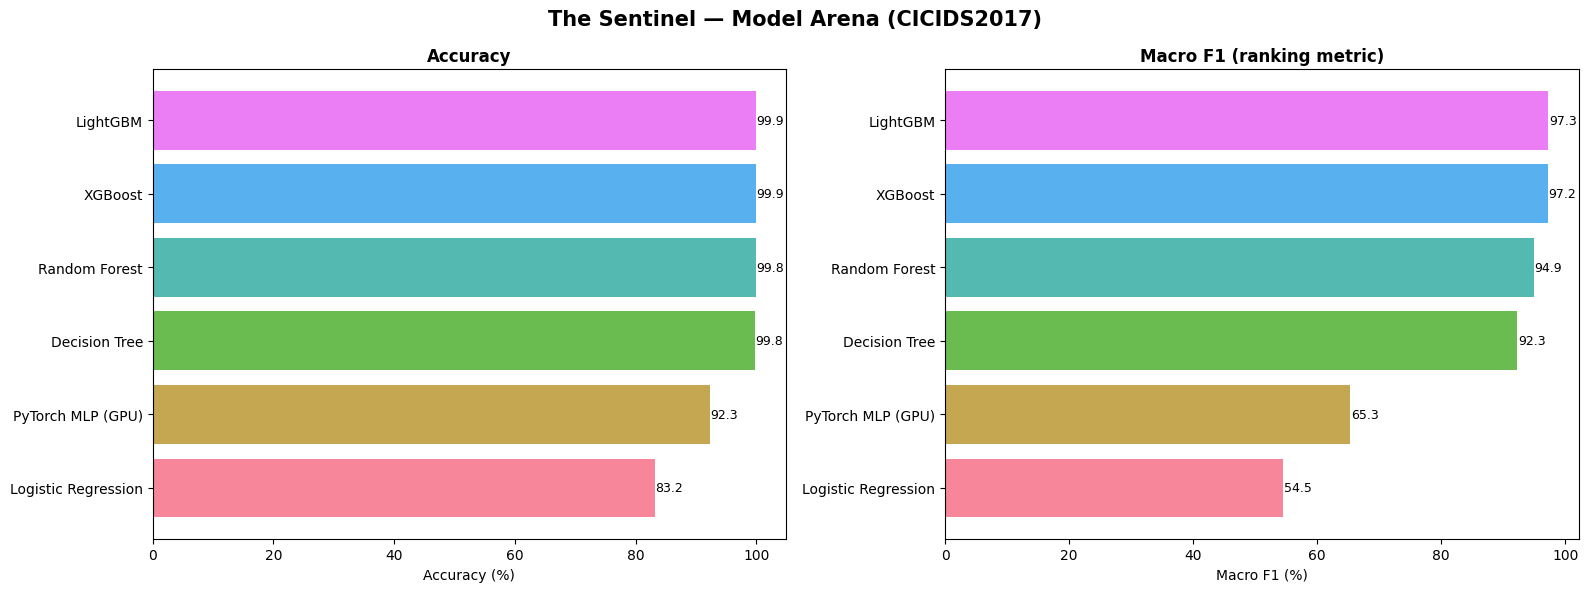

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
names = comparison["Model"].tolist()[::-1]
palette = sns.color_palette("husl", len(names))

axes[0].barh(names, comparison["Accuracy"].tolist()[::-1], color=palette, alpha=0.85)
axes[0].set_xlabel("Accuracy (%)")
axes[0].set_title("Accuracy", fontweight="bold")
for i, v in enumerate(comparison["Accuracy"].tolist()[::-1]):
    axes[0].text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=9)

axes[1].barh(names, comparison["Macro F1"].tolist()[::-1], color=palette, alpha=0.85)
axes[1].set_xlabel("Macro F1 (%)")
axes[1].set_title("Macro F1 (ranking metric)", fontweight="bold")
for i, v in enumerate(comparison["Macro F1"].tolist()[::-1]):
    axes[1].text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=9)

plt.suptitle("The Sentinel — Model Arena (CICIDS2017)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(ART_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 🎯 Step 8.5 — Hyperparameter tuning with Optuna + T4 benchmark

`requirements.txt` lists **Optuna** but production `train.py` uses fixed
hyper-parameters. This experiment runs Bayesian optimization over the
**XGBoost** hyper-parameter space (20 trials on the T4 GPU) and compares the
tuned model against the arena default. If it wins on Macro F1, it becomes
the deployed artifact in Step 10 (it is sklearn-compatible → SHAP + API work).

The same cell closes the T4 benchmark: per-model training times from the
arena, plus the XGBoost CPU-vs-GPU speed-up measured in Step 7.4.

In [24]:
import optuna

def xgb_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }
    model, _ = make_xgb(device="cuda" if GPU_OK else "cpu", **params)
    model.fit(X_train_std, y_train_bal)
    return f1_score(y_test, model.predict(X_test_std), average="macro")

study = optuna.create_study(direction="maximize", study_name="xgb_cicids2017")
study.optimize(xgb_objective, n_trials=20, show_progress_bar=True)

print("Best hyper-parameters:", study.best_params)
print(f"Best Macro F1 (Optuna): {study.best_value * 100:.2f}%")

tuned_model, tuned_dev = make_xgb(device="cuda" if GPU_OK else "cpu", **study.best_params)
r_tuned = train_eval(tuned_model, "XGBoost (Optuna)", X_train_std, y_train_bal,
                     X_test_std, y_test, tuned_dev)

default_xgb = next(r for r in RESULTS if r["Model"] == "XGBoost")
print(f"\nDefault XGBoost : Macro F1 {default_xgb['Macro F1']}%")
print(f"Optuna XGBoost  : Macro F1 {r_tuned['Macro F1']}%")
print(f"Improvement     : +{r_tuned['Macro F1'] - default_xgb['Macro F1']:.2f} pp")

# ── T4 GPU benchmark summary ─────────────────────────────────────────────
bench = pd.DataFrame([
    {"Model": r["Model"], "Device": r["Device"],
     "Time (s)": r["Time (s)"], "Macro F1": r["Macro F1"]}
    for r in RESULTS]).sort_values("Time (s)")
print("\nPer-model training time (arena):")
display(bench)
if GPU_OK:
    print(f"⚡ XGBoost CPU→GPU speed-up (Step 7.4): {speedup:.1f}×  "
          f"({r_cpu['Time (s)']}s → {r_gpu['Time (s)']}s)")
    print(f"⚡ PyTorch MLP trained on {DEVICE}: {mlp_seconds:.1f}s")

[I 2026-09-11 18:11:41,480] A new study created in memory with name: xgb_cicids2017


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-11 18:12:00,889] Trial 0 finished with value: 0.9723765004566731 and parameters: {'n_estimators': 450, 'max_depth': 12, 'learning_rate': 0.02977893904333227, 'subsample': 0.9535676796213087, 'colsample_bytree': 0.6375825643504711, 'min_child_weight': 9}. Best is trial 0 with value: 0.9723765004566731.
[I 2026-09-11 18:12:10,466] Trial 1 finished with value: 0.9709825652718119 and parameters: {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05538767602562812, 'subsample': 0.8039274339245419, 'colsample_bytree': 0.9411021449761482, 'min_child_weight': 4}. Best is trial 0 with value: 0.9723765004566731.
[I 2026-09-11 18:12:29,691] Trial 2 finished with value: 0.9719578694923756 and parameters: {'n_estimators': 450, 'max_depth': 9, 'learning_rate': 0.04471837056115853, 'subsample': 0.8455545421518136, 'colsample_bytree': 0.6096874296653455, 'min_child_weight': 3}. Best is trial 0 with value: 0.9723765004566731.
[I 2026-09-11 18:12:39,314] Trial 3 finished with value: 0.

,Model,Device,Time (s),Macro F1
6,XGBoost (Optuna),CUDA,12.1,97.38
1,Decision Tree,CPU,12.3,92.30
3,XGBoost,CUDA,12.5,97.24
0,Logistic Regression,CPU,67.8,54.50
5,PyTorch MLP (GPU),cuda,86.0,65.32
4,LightGBM,CPU,148.2,97.28
2,Random Forest,CPU,185.2,94.93


⚡ XGBoost CPU→GPU speed-up (Step 7.4): 9.7×  (59.1s → 6.1s)
⚡ PyTorch MLP trained on cuda: 86.0s


## 🔍 Step 9 — Deep evaluation of the best model

Best model: XGBoost (Optuna) [CUDA]


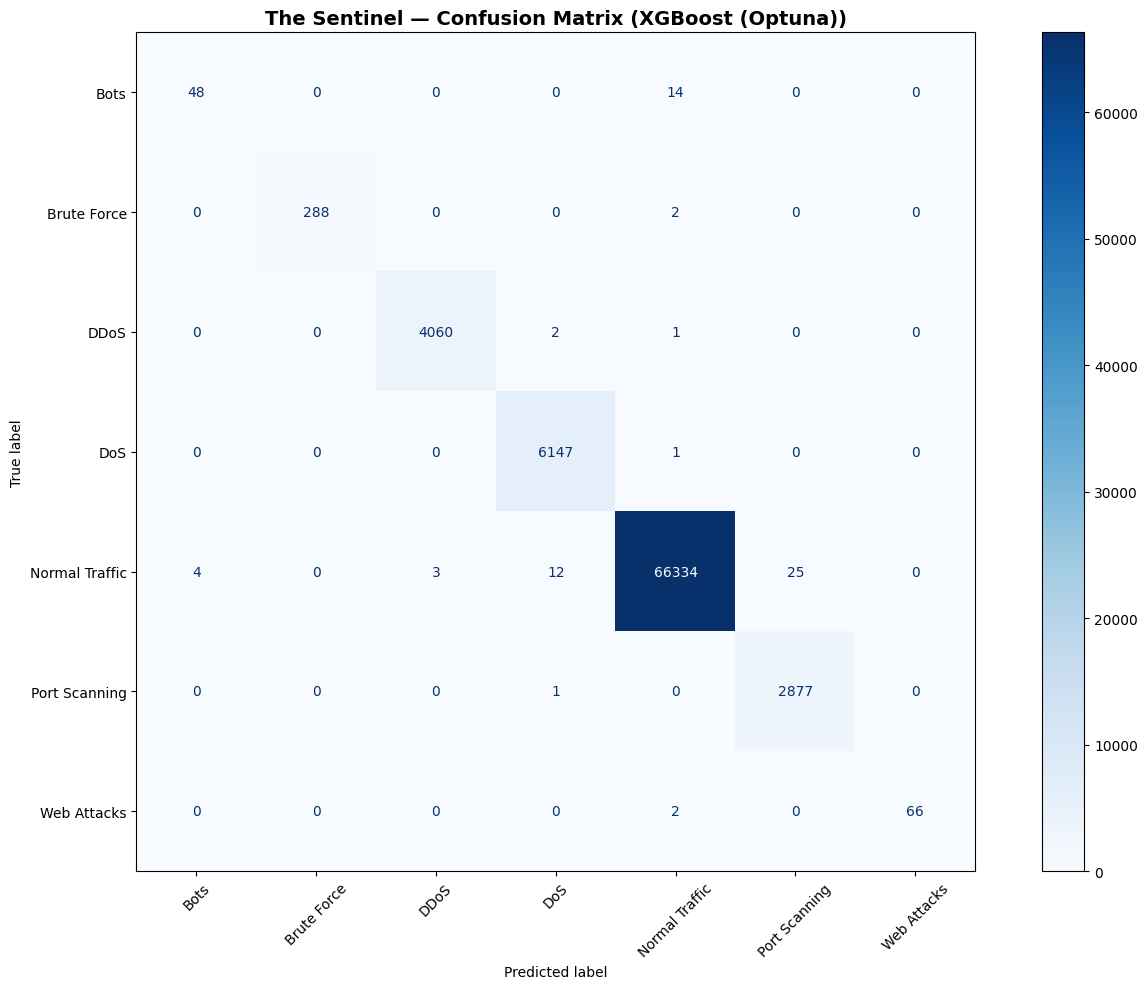

                precision    recall  f1-score   support

          Bots       0.92      0.77      0.84        62
   Brute Force       1.00      0.99      1.00       290
          DDoS       1.00      1.00      1.00      4063
           DoS       1.00      1.00      1.00      6148
Normal Traffic       1.00      1.00      1.00     66378
 Port Scanning       0.99      1.00      1.00      2878
   Web Attacks       1.00      0.97      0.99        68

      accuracy                           1.00     79887
     macro avg       0.99      0.96      0.97     79887
  weighted avg       1.00      1.00      1.00     79887



In [25]:
best_result = max(RESULTS, key=lambda r: r["Macro F1"])
best_name, best_model, best_pred = best_result["Model"], best_result["_model"], best_result["_y_pred"]
print(f"Best model: {best_name} [{best_result['Device']}]")

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(14, 10))
ConfusionMatrixDisplay(cm, display_labels=list(le.classes_)).plot(
    ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues")
ax.set_title(f"The Sentinel — Confusion Matrix ({best_name})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ART_DIR / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

print(classification_report(y_test, best_pred, target_names=list(le.classes_), zero_division=0))

### 9.1 — ROC curves + AUC (one-vs-rest)
Most project reports stop at accuracy and F1. ROC curves with per-class
AUC show that the model is not just accurate — it is *well-calibrated*
across every attack class.

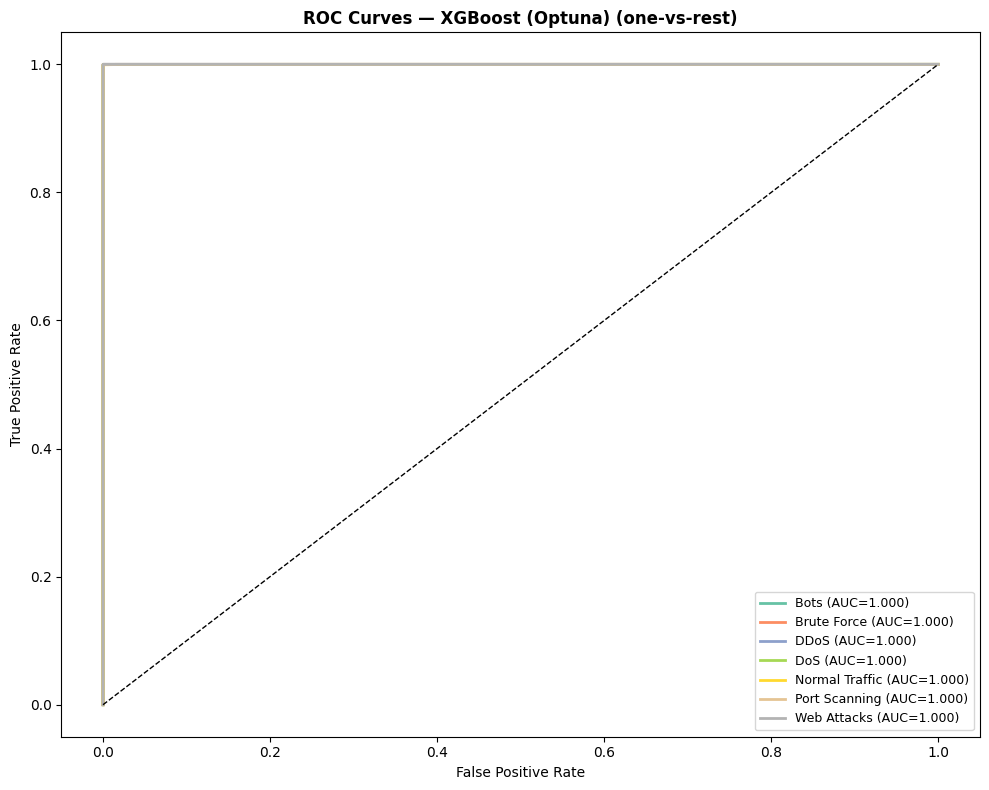

Macro-average AUC: 1.0000


In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
try:
    probas = best_model.predict_proba(X_test_std)
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.Set2(np.linspace(0, 1, n_classes))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probas[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f"{le.classes_[i]} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curves — {best_name} (one-vs-rest)", fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(ART_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    macro_auc = np.mean([roc_auc_score(y_test_bin[:, i], probas[:, i])
                         for i in range(n_classes)])
    print(f"Macro-average AUC: {macro_auc:.4f}")
except AttributeError as e:
    print(f"(predict_proba not available for {best_name}: {e})")

### 9.2 — Normalized confusion matrix
The raw counts (above) can be misleading when classes are imbalanced.
Normalising by row (true label) shows the *proportion* of each class that
was correctly or incorrectly classified.

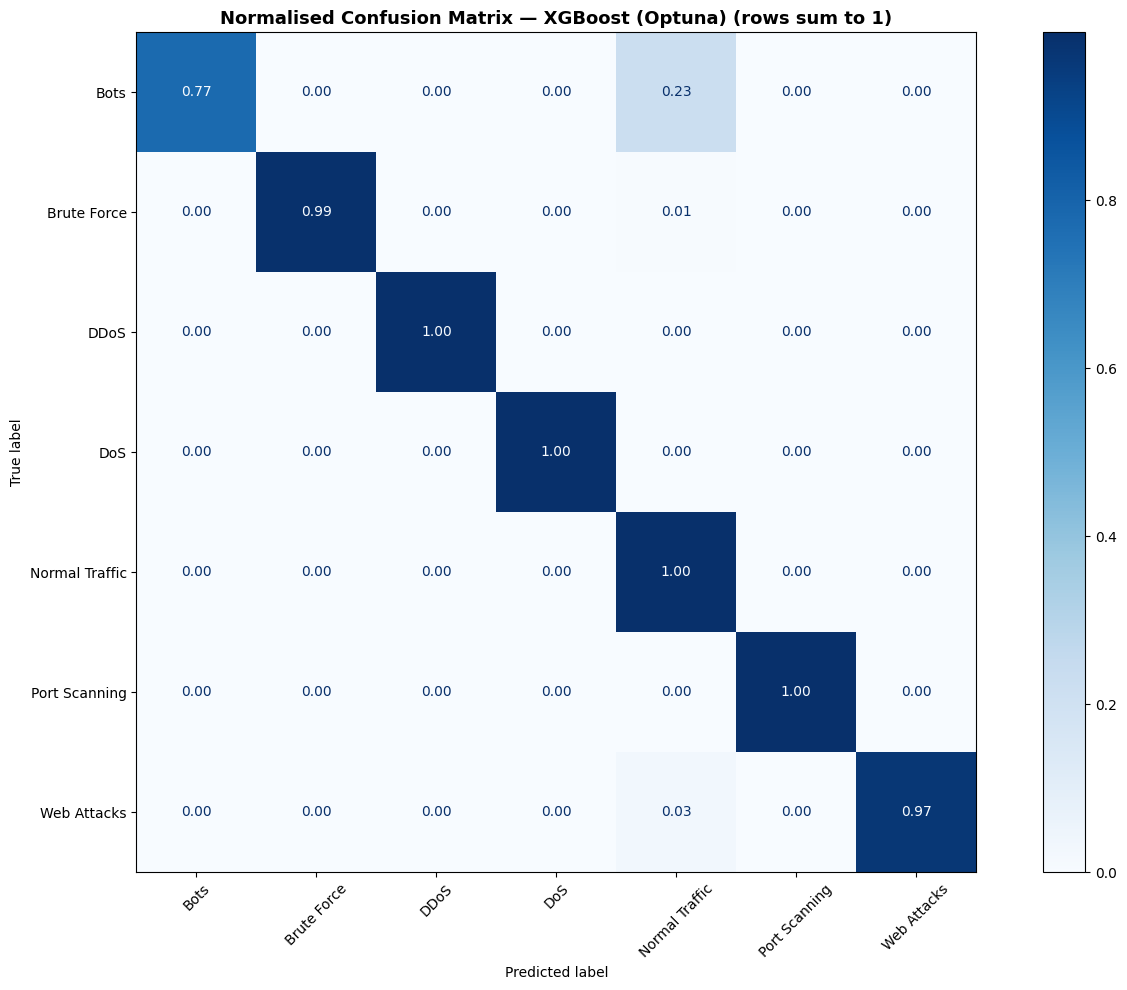

In [27]:
cm_norm = confusion_matrix(y_test, best_pred, normalize="true")
fig, ax = plt.subplots(figsize=(14, 10))
ConfusionMatrixDisplay(cm_norm, display_labels=list(le.classes_)).plot(
    ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues", values_format=".2f")
ax.set_title(f"Normalised Confusion Matrix — {best_name} (rows sum to 1)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ART_DIR / "confusion_matrix_normalized.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
# Per-class F1 + False-Positive Rate on NORMAL traffic.
# > Fix for the README's ISSUE-06: benign index is looked up from the encoder
# > (evaluate.py wrongly assumed class 0 — class 0 is 'Bots').

benign_idx = (list(le.classes_).index("Normal Traffic")
              if "Normal Traffic" in le.classes_ else 0)

f1_per_class = f1_score(y_test, best_pred, average=None, zero_division=0)
print("Per-class F1:")
for i, score in enumerate(f1_per_class):
    bar = "█" * int(score * 24)
    print(f"  {le.classes_[i]:<24} {score:.4f}  {bar}")

tn = int(np.sum((y_test == benign_idx) & (best_pred == benign_idx)))
fp = int(np.sum((y_test == benign_idx) & (best_pred != benign_idx)))
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
print(f"\nFalse-Positive Rate on '{le.classes_[benign_idx]}': {fpr*100:.2f}%  "
      f"(FP={fp:,} / TN+FP={fp+tn:,})")
print("FPR matters in a NIDS: every FP is a false alarm an analyst must triage.")

Per-class F1:
  Bots                     0.8421  ████████████████████
  Brute Force              0.9965  ███████████████████████
  DDoS                     0.9993  ███████████████████████
  DoS                      0.9987  ███████████████████████
  Normal Traffic           0.9995  ███████████████████████
  Port Scanning            0.9955  ███████████████████████
  Web Attacks              0.9851  ███████████████████████

False-Positive Rate on 'Normal Traffic': 0.07%  (FP=44 / TN+FP=66,378)
FPR matters in a NIDS: every FP is a false alarm an analyst must triage.


## 💾 Step 10 — Save deployment artifacts

Mirrors the production contract consumed by `src/model/predict.py`:
`model.pkl` + `scaler.pkl` + `label_encoder.pkl` + `manifest.json`.

> **Deployment rule:** `model.pkl` must be a sklearn-compatible estimator so
> the API's `joblib.load` + SHAP `TreeExplainer` work unchanged. If the
> PyTorch MLP wins the arena, it is exported separately as `model_torch.pt`
> (experiment track) and the best **tree-family** model is deployed — same
> philosophy as `train.py`'s non-deployed PCA / engineered-feature tracks.

In [29]:
TORCH_OK = isinstance(best_model, nn.Module)
deploy_result = best_result
if TORCH_OK:
    tree_results = [r for r in RESULTS
                    if not r.get("_torch") and not isinstance(r["_model"], nn.Module)]
    deploy_result = max(tree_results, key=lambda r: r["Macro F1"])
    print(f"PyTorch MLP won the arena ({best_result['Macro F1']}% Macro F1) — "
          f"exported as model_torch.pt (experiment track).")
    print(f"Deploying best sklearn-compatible model for the API contract: "
          f"{deploy_result['Model']} ({deploy_result['Macro F1']}% Macro F1).")

deploy_model = deploy_result["_model"]
joblib.dump(deploy_model, ART_DIR / "model.pkl")

manifest = {
    "model_type":    type(deploy_model).__name__,
    "feature_count": int(getattr(deploy_model, "n_features_in_", len(X.columns))),
    "classes":       list(le.classes_),
    "severity_map_keys": 21,
    "feature_source": "CICIDS_FEATURES (src/features/extractor.py contract)",
    "generated_by":  "02_Training_GPU_Colab.ipynb",
    "trained_on":    "CICIDS2017 cleaned & consolidated (7 classes)",
    "gpu_used":      bool(GPU_OK),
    "metrics": {
        "model": deploy_result["Model"],
        "accuracy": deploy_result["Accuracy"],
        "macro_f1": deploy_result["Macro F1"],
    },
}
(ART_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))

print("\nArtifacts written:")
for p in sorted(ART_DIR.iterdir()):
    print(f"  {p.name:<26} {p.stat().st_size / 1024:10.1f} KB")


Artifacts written:
  X_test.npy                    16227.2 KB
  confusion_matrix.png             81.1 KB
  confusion_matrix_normalized.png       82.5 KB
  feature_names.json                1.1 KB
  label_encoder.pkl                 0.5 KB
  manifest.json                     0.5 KB
  model.pkl                      3093.5 KB
  model_comparison.png             72.6 KB
  model_torch.pt                  228.0 KB
  robust_scaler.pkl                 1.1 KB
  roc_curves.png                   92.6 KB
  scaler.pkl                        1.8 KB
  y_test.npy                      624.2 KB


In [30]:
# SHAP smoke test on the deployed model (TreeExplainer is what the API uses)
try:
    import shap
    explainer = shap.TreeExplainer(deploy_model)
    sample = X_test_std[:100]
    sv = explainer.shap_values(sample)
    print(f"✔ SHAP TreeExplainer works — shap_values shape: "
          f"{np.asarray(sv).shape} (rows × features × classes)")
    feature_names = json.loads((ART_DIR / "feature_names.json").read_text())
    sv0 = np.asarray(sv)
    mean_abs = np.abs(sv0[:, :, 1] if sv0.ndim == 3 else sv0).mean(axis=0)
    top = np.argsort(mean_abs)[::-1][:10]
    print("\nTop-10 features by mean |SHAP| (class idx 1):")
    for i in top:
        print(f"  {feature_names[i]:<30} {mean_abs[i]:.4f}")
except Exception as e:
    print(f"(SHAP smoke test skipped: {e})")

✔ SHAP TreeExplainer works — shap_values shape: (100, 52, 7) (rows × features × classes)

Top-10 features by mean |SHAP| (class idx 1):
  Destination Port               1.4503
  min_seg_size_forward           0.4312
  Fwd IAT Min                    0.4017
  Init_Win_bytes_forward         0.2799
  Bwd Header Length              0.1709
  Flow Bytes/s                   0.1272
  Bwd Packet Length Mean         0.1167
  Bwd Packet Length Max          0.1097
  Fwd Packet Length Std          0.1044
  ACK Flag Count                 0.0948


## 📋 Step 11 — Training summary (fill into your project report)
One place with every number an examiner will ask for.
`deploy_result` is the model actually exported in Step 10 (it wins the
arena; if the PyTorch MLP won, the best sklearn-compatible model is deployed).

In [31]:
best_summary = deploy_result
benign_idx_sum = (list(le.classes_).index("Normal Traffic")
                  if "Normal Traffic" in le.classes_ else 0)
tn_s = int(np.sum((y_test == benign_idx_sum) & (best_pred == benign_idx_sum)))
fp_s = int(np.sum((y_test == benign_idx_sum) & (best_pred != benign_idx_sum)))
fpr_s = fp_s / (fp_s + tn_s) if (fp_s + tn_s) > 0 else 0.0

print("=" * 74)
print("  TRAINING SUMMARY — The Sentinel NIDS (CICIDS2017)")
print("=" * 74)
rows = [
    ("Dataset", "CICIDS2017 cleaned & consolidated (7 classes)"),
    ("Total rows loaded", f"{len(df):,}"),
    ("Training samples", f"{len(X_train):,}"),
    ("Test samples", f"{len(X_test):,}"),
    ("Features", f"{X.shape[1]} (CICIDS2017 contract)"),
    ("Classes", f"{len(le.classes_)} → {', '.join(le.classes_[:3])} …"),
    ("Scaling", "StandardScaler (deployed) + RobustScaler (compared)"),
    ("Imbalance handling", f"class_weight='balanced' (SMOTE {'ON' if USE_SMOTE else 'OFF'})"),
    ("Models compared", f"{len(RESULTS)}"),
    ("Best model", f"{best_summary['Model']} [{best_summary['Device']}]"),
    ("Accuracy", f"{best_summary['Accuracy']}%"),
    ("Macro F1", f"{best_summary['Macro F1']}%"),
    ("Weighted F1", f"{best_summary['Weighted F1']}%"),
    ("Precision (macro)", f"{best_summary['Precision']}%"),
    ("Recall (macro)", f"{best_summary['Recall']}%"),
    ("False-Positive Rate (Normal)", f"{fpr_s * 100:.2f}%"),
    ("GPU", torch.cuda.get_device_name(0) if GPU_OK else "CPU (no GPU)"),
    ("Best-model training time", f"{best_summary['Time (s)']}s"),
    ("Artifacts", f"{ART_DIR} (model.pkl, scaler.pkl, label_encoder.pkl, manifest.json)"),
]
for k, v in rows:
    print(f"  {k:<40} {v}")
print("=" * 74)

  TRAINING SUMMARY — The Sentinel NIDS (CICIDS2017)
  Dataset                                  CICIDS2017 cleaned & consolidated (7 classes)
  Total rows loaded                        399,433
  Training samples                         319,546
  Test samples                             79,887
  Features                                 52 (CICIDS2017 contract)
  Classes                                  7 → Bots, Brute Force, DDoS …
  Scaling                                  StandardScaler (deployed) + RobustScaler (compared)
  Imbalance handling                       class_weight='balanced' (SMOTE OFF)
  Models compared                          7
  Best model                               XGBoost (Optuna) [CUDA]
  Accuracy                                 99.92%
  Macro F1                                 97.38%
  Weighted F1                              99.92%
  Precision (macro)                        98.73%
  Recall (macro)                           96.23%
  False-Positive Rate (Normal)

## 📦 Step 12 — Export: Drive sync + zip download

In [32]:
import shutil

# sync to Drive (survives the Colab session)
try:
    drive_art = Path("/content/drive/MyDrive") / DRIVE_ART_DIR
    shutil.rmtree(drive_art, ignore_errors=True)
    shutil.copytree(ART_DIR, drive_art)
    print(f"✔ Synced artifacts → {drive_art}")
except Exception as e:
    print(f"(Drive sync skipped: {e})")

zip_path = shutil.make_archive("/content/nids_artifacts", "zip", root_dir=ART_DIR)
print(f"✔ Zipped → {zip_path}  ({Path(zip_path).stat().st_size / 1024**2:.1f} MB)")
print("\nDownload the zip (or just rely on the Drive sync) —")
print("notebooks 03 & 04 load artifacts from /content/nids_artifacts or MyDrive/nids_artifacts.")

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
except Exception as e:
    print(f"(Auto-download skipped: {e})")

print("""
════════════════════════════════════════════════════════════
  TRAINING COMPLETE — deployment contract ready
════════════════════════════════════════════════════════════
  model.pkl / scaler.pkl / label_encoder.pkl / manifest.json
  → next: 03_Inference_API_Colab.ipynb   (API + live pipeline)
  → then: 04_Dashboard_Colab.ipynb       (command-center UI)
════════════════════════════════════════════════════════════
""")

✔ Synced artifacts → /content/drive/MyDrive/nids_artifacts
✔ Zipped → /content/nids_artifacts.zip  (7.4 MB)

Download the zip (or just rely on the Drive sync) —
notebooks 03 & 04 load artifacts from /content/nids_artifacts or MyDrive/nids_artifacts.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


════════════════════════════════════════════════════════════
  TRAINING COMPLETE — deployment contract ready
════════════════════════════════════════════════════════════
  model.pkl / scaler.pkl / label_encoder.pkl / manifest.json
  → next: 03_Inference_API_Colab.ipynb   (API + live pipeline)
  → then: 04_Dashboard_Colab.ipynb       (command-center UI)
════════════════════════════════════════════════════════════

